# EDA Post-merge

 To begin, we load the tools we will need. These are Python libraries that help us work with data, do calculations, and potentially create graphs.

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

What this instruction does is to read a CSV file named spotify_grammy_merged.csv located in the path ../data/2_final/ and load it into a pandas DataFrame and displays the first 5 rows of the DataFrame.

In [17]:
df = pd.read_csv('../data/2_final/spotify_grammy_merged.csv')
df.head()

,track_id,track_genre,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,popularity_category,winner
0,0000vdrevcvmxbqtks888c,german,rill,lolly,lolly,44,160725,True,0.910,0.374,...,0,0.1990,0.075700,0.00301,0.1540,0.432,104.042,4,medium,False
1,000cc8eparg64omtxvnz0p,club,glee cast,glee love songs,it's all coming back to me now (glee cast vers...,47,322933,False,0.269,0.516,...,1,0.0366,0.406000,0.00000,0.1170,0.341,178.174,4,medium,False
2,000iz0k615uepwsj5z2re5,minimal-techno,paul kalkbrenner;pig&dan,x,böxig leise - pig & dan remix,22,515360,False,0.686,0.560,...,0,0.0462,0.001140,0.18100,0.1110,0.108,119.997,4,low,False
3,000qpdoc97imtbvf8gwcpy,minimal-techno,paul kalkbrenner,zeit,tief,19,331240,False,0.519,0.431,...,0,0.0291,0.000964,0.72000,0.0916,0.234,129.971,4,very low,False
4,000rdcyioltexcutojewey,hip-hop,jordan sandhu,teeje week,teeje week,62,190203,False,0.679,0.770,...,1,0.1900,0.058300,0.00000,0.0825,0.839,161.721,4,high,False


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92167 entries, 0 to 92166
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             92167 non-null  object 
 1   track_genre          92167 non-null  object 
 2   artists              92167 non-null  object 
 3   album_name           92167 non-null  object 
 4   track_name           92167 non-null  object 
 5   popularity           92167 non-null  int64  
 6   duration_ms          92167 non-null  int64  
 7   explicit             92167 non-null  bool   
 8   danceability         92167 non-null  float64
 9   energy               92167 non-null  float64
 10  key                  92167 non-null  int64  
 11  loudness             92167 non-null  float64
 12  mode                 92167 non-null  int64  
 13  speechiness          92167 non-null  float64
 14  acousticness         92167 non-null  float64
 15  instrumentalness     92167 non-null 

The spotify_grammy_merged.csv dataset contains 92,167 rows and 22 columns, with information about songs that participated in the Grammy Awards. Each row represents a song and its characteristics, such as unique identifier (track_id), genre (track_genre), artists (artists), album name (album_name), popularity (popularity), and musical characteristics such as duration (duration_ms), energy (energy), danceability (danceability), and key (key), among others. In addition, the columns include whether the song contains explicit content (explicit), its popularity category (popularity_category), and whether it won a Grammy (winner). The data are complete, with no null values, and are ready to perform analysis on the success of the songs and the characteristics that influence their performance at the Grammy Awards.

In [19]:
df['winner'].value_counts()


winner
False    87519
True      4648
Name: count, dtype: int64

In the descriptive analysis of the spotify_grammy_merged.csv dataset, when reviewing the winner column, we observe that there are 87,519 songs that did not win a Grammy and 4,648 that did. This reflects a rather uneven distribution, where most of the songs did not achieve the award, which could be interesting to analyze if there are specific factors or characteristics that influence the winning songs compared to the non-winners.

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,92167.0,33.343019,20.928436,0.000,19.0000,33.000000,49.00000,100.000
duration_ms,92167.0,229120.699426,112156.866636,8586.000,173053.0000,213453.000000,264059.50000,5237295.000
danceability,92167.0,0.562152,0.176047,0.000,0.4490,0.576000,0.69200,0.985
energy,92167.0,0.633251,0.256091,0.000,0.4560,0.674000,0.85100,1.000
key,92167.0,5.278028,3.559527,0.000,2.0000,5.000000,8.00000,11.000
loudness,92167.0,-8.482301,5.182039,-49.531,-10.3110,-7.185000,-5.11400,4.532
mode,92167.0,0.639882,0.480037,0.000,0.0000,1.000000,1.00000,1.000
speechiness,92167.0,0.086651,0.112232,0.000,0.0358,0.048600,0.08490,0.965
acousticness,92167.0,0.328598,0.337903,0.000,0.0174,0.189000,0.62500,0.996
instrumentalness,92167.0,0.170518,0.321535,0.000,0.0000,0.000055,0.08695,1.000


In the descriptive analysis of the main features of the spotify_grammy_merged.csv dataset, several important metrics are observed that summarize the behavior of the variables. For example:

Popularity: The average popularity value is 33.34, with a range from 0 to 100, indicating that most songs have moderate popularity, but there are some exceptions with values ​​close to 0.

Duration: The average song length is approximately 229.120 ms (229 seconds or almost 4 minutes), with wide variability between short and long songs, with a maximum of over 5 minutes.

Danceability and Energy: These features have average values ​​of approximately 0.56 and 0.63, respectively, suggesting that the songs tend to have moderate danceability and moderately high energy.

Loudness: The average loudness is -8.48 dB, indicating that most songs are relatively soft, with some values ​​reaching as high as 4.53 dB.

Speechiness and Acoustics: These characteristics show a low average, with values ​​of 0.09 and 0.33 respectively, indicating that most songs are neither predominantly spoken nor acoustic.

Instrumentality: The average is 0.17, indicating that a significant proportion of songs have low instrumentation.

Valence: The average is 0.47, reflecting that the songs tend to be emotionally neutral.

Tempo: The average tempo is 122 BPM, ranging from very low values ​​to values ​​close to 243 BPM.

In summary, most songs in the dataset tend to have moderate characteristics in terms of popularity, energy, and other musical aspects, while duration and volume can vary more widely.

# Visualizations

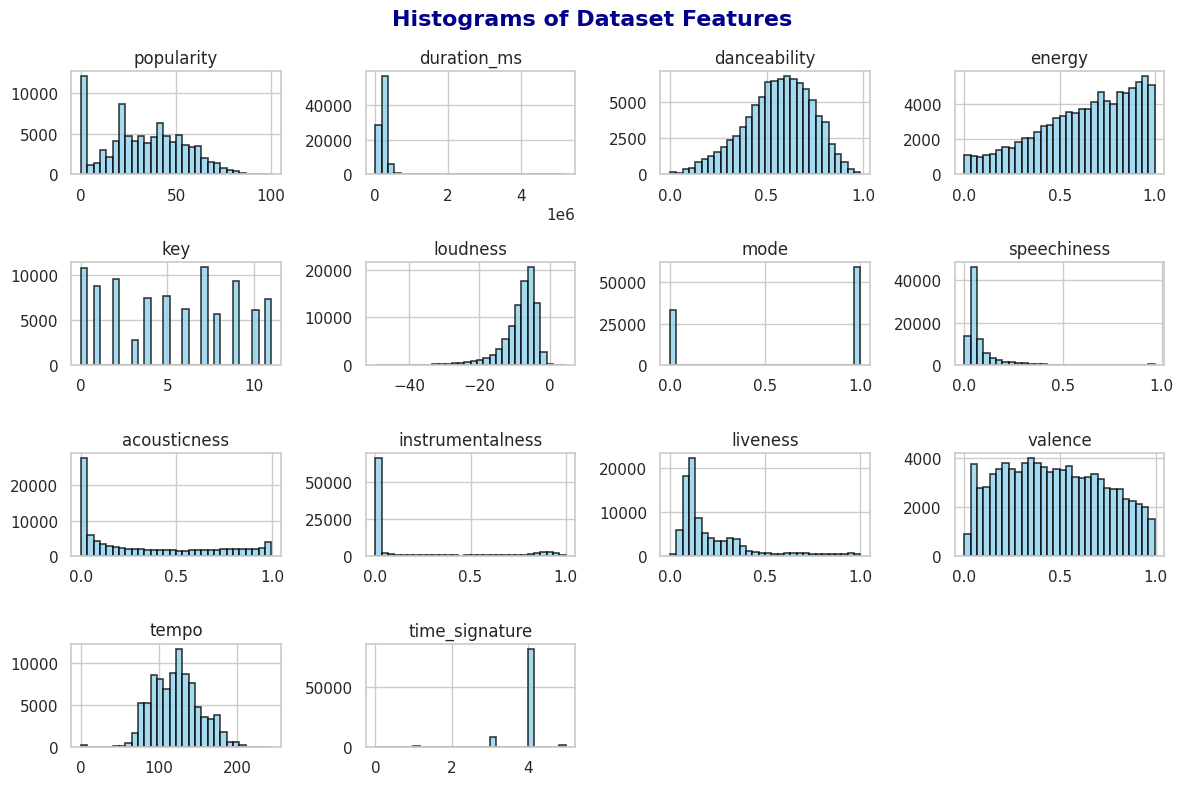

In [21]:
df.hist(figsize=(12, 8), bins=30, color="skyblue", edgecolor="black", alpha=0.75, grid=True, linewidth=1.2)
plt.suptitle("Histograms of Dataset Features", fontsize=16, fontweight="bold", color="darkblue")
plt.tight_layout()

plt.show()

The "Histograms of Dataset Features" set of histograms shows the distribution of musical features in the dataset: popularity is skewed to the right with a peak at 0-25 (most songs have low popularity); duration_ms peaks around 200,000 ms (3-4 minutes) with some extreme values ​​up to 1M ms; danceability, energy, speechiness, acousticness, instrumentalness, liveness, and valence are distributed between 0 and 1, with danceability and energy concentrated at 0.5-0.75 (danceable and energetic songs), speechiness, acousticness, instrumentalness, and liveness skewed towards 0 (little spoken, acoustic, instrumental, or live), and valence more even (variety in mood); key has peaks at 0, 1, 4, 5, 7, 9 (common keys like C, D, F), loudness is concentrated between -10 and 0 dB (typical volume), mode is mostly 1 (major key), tempo has a peak at 100-150 BPM (standard rhythm), and time_signature is predominantly 4 (4/4 time), indicating a dataset of mostly popular songs, in major keys, with standard rhythms and durations, and little presence of acoustic, spoken or instrumental elements.

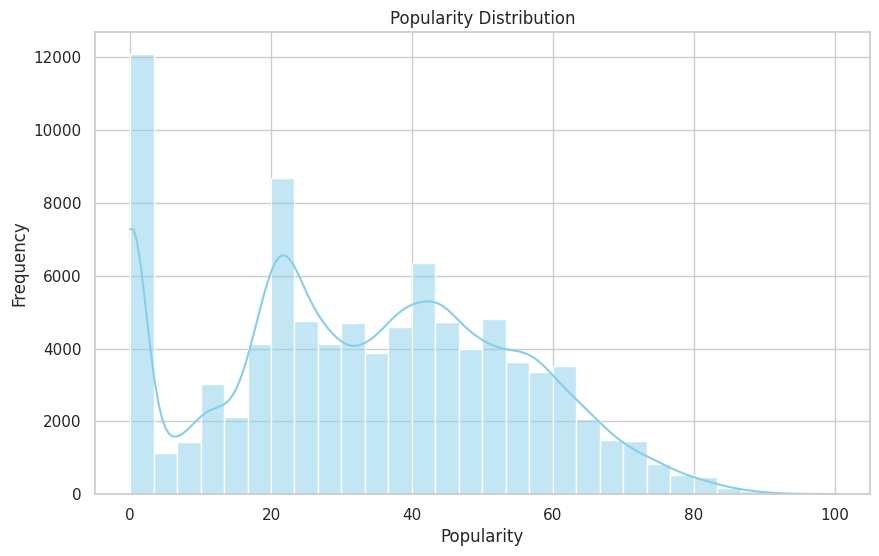

/tmp/ipykernel_180616/3823341418.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")


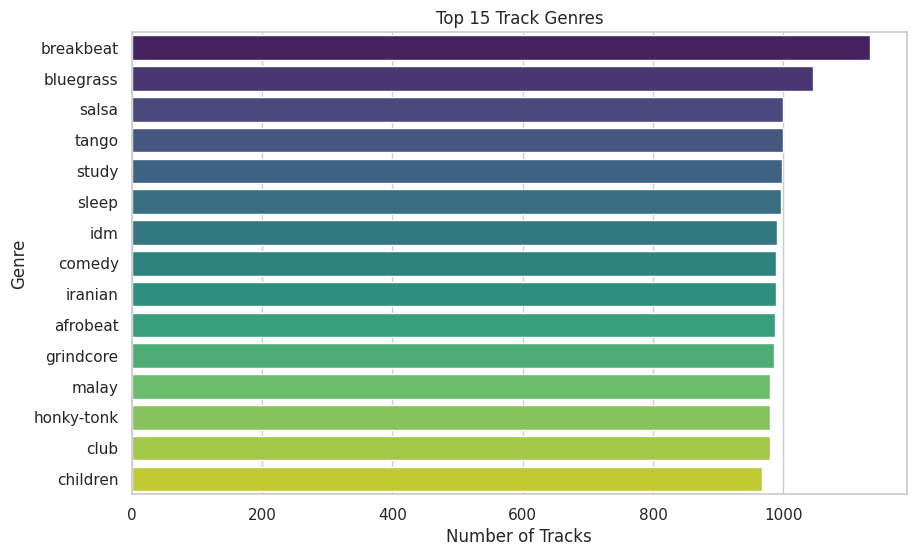

/tmp/ipykernel_180616/3823341418.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='explicit', palette="Set2")


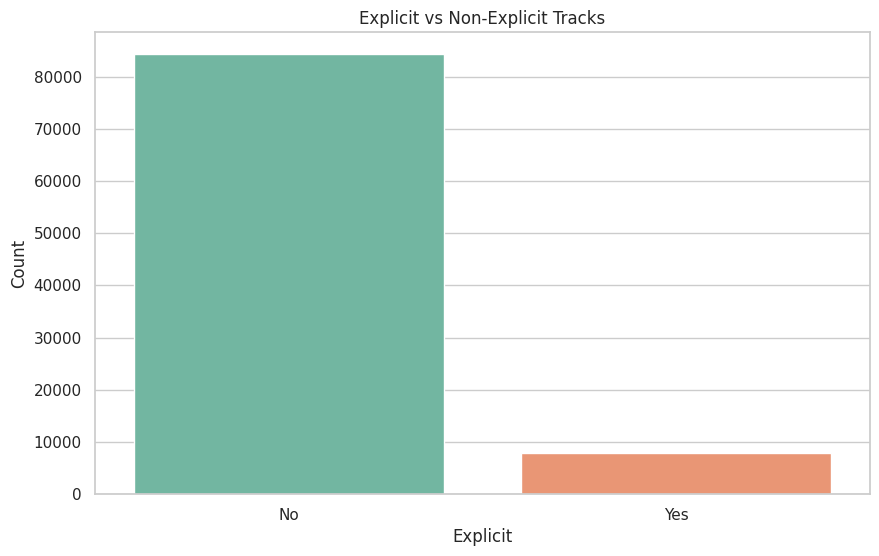

In [22]:

sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

sns.histplot(data=df, x='popularity', bins=30, kde=True, color="skyblue")
plt.title('Popularity Distribution')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.show()

top_genres = df['track_genre'].value_counts().nlargest(15)
sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
plt.title('Top 15 Track Genres')
plt.xlabel('Number of Tracks')
plt.ylabel('Genre')
plt.show()

sns.countplot(data=df, x='explicit', palette="Set2")
plt.title('Explicit vs Non-Explicit Tracks')
plt.xlabel('Explicit')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()


The "Popularity Distribution" histogram shows that the popularity of songs in the dataset has a multimodal distribution with peaks at 0-10 (around 12,000 songs), 30-40 (around 8,000), and 50-60 (around 6,000), and decreasing towards higher values, with very few songs exceeding a popularity of 80, indicating that most songs have low to moderate popularity (0-60), with distinct clusters of songs that are more popular at specific ranges, possibly reflecting different levels of commercial success or exposure.

The graph shows the top 15 song genres present in the data set. Breakbeat ranks first, with over 10,000 entries. Bluegrass follows, also exceeding 1,000 entries, and salsa ranks last, with nearly 1,000 entries.

The graph shows a comparison between explicit and non-explicit songs, the graph shows us that the songs categorized as non-explicit are more than 80 in the dataset, while the explicit ones do not exceed 10,000 data.